# Retrieve and Process Hydrology Data for Starvation Reservoir

This notebook downloads and processes SNOTEL SWE and USGS streamflow data for the Starvation Reservoir basin on the Strawberry River in Utah. Data is saved to the `data/` folder for use in the analysis notebook.

**SNOTEL Site:** Strawberry Divide (795:UT:SNTL)
**USGS Gauge:** 09285900 - Strawberry River at Pinnacles near Fruitland, UT

In [13]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pynhd import NLDI
from dataretrieval import nwis
import warnings
warnings.filterwarnings('ignore')

# create output folders if they don't exist
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)
os.makedirs('files', exist_ok=True)

## Delineate Watershed and Map Area of Interest

Use the NLDI to delineate the basin upstream of USGS gauge 09285900. Then load all SNOTEL station locations and clip to the basin boundary to find stations within the watershed. The map shows the watershed boundary, USGS gauge location, and SNOTEL station.

In [14]:
# delineate basin upstream of the USGS gauge using NLDI
nldi = NLDI()
print('Delineating basin...', end='')
basin = nldi.get_basins('09285900')
basin.to_file('files/StarvationReservoirBasin.shp')
print('done')

# get the gauge point location
site_feature = nldi.getfeature_byid('nwissite', 'USGS-09285900')

Delineating basin...done


In [15]:
# load all SNOTEL station locations from GitHub
all_stations = (
    gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson')
    .set_index('code')
)
all_stations = all_stations[all_stations['csvData'] == True]

# clip to basin boundary
gdf_in_bbox = all_stations[
    all_stations.geometry.within(basin.geometry.iloc[0])
].reset_index(drop=False)

print(f'Found {len(gdf_in_bbox)} SNOTEL site(s) within the basin:')
gdf_in_bbox[['code', 'name', 'elevation_m', 'latitude', 'longitude']]

Found 1 SNOTEL site(s) within the basin:


,code,name,elevation_m,latitude,longitude
0,795_UT_SNTL,Strawberry Divide,2475.890381,40.164829,-111.20665


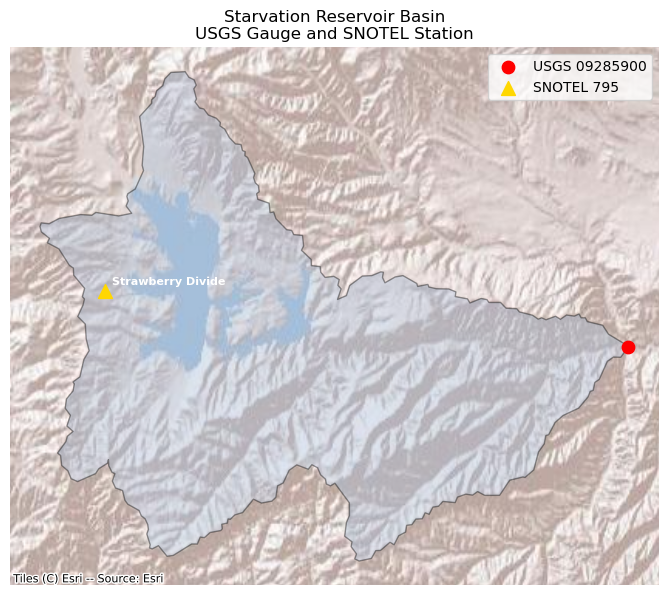

In [21]:
import contextily as ctx

# map the basin, USGS gauge, and SNOTEL station
fig, ax = plt.subplots(figsize=(7, 6))

# reproject to Web Mercator for basemap compatibility
basin_wm       = basin.to_crs(epsg=3857)
site_wm        = site_feature.to_crs(epsg=3857)
gdf_wm         = gdf_in_bbox.to_crs(epsg=3857)

# plot basin polygon
basin_wm.plot(ax=ax, facecolor='lightsteelblue', edgecolor='black', alpha=0.4)

# plot USGS gauge as red circle
site_wm.plot(ax=ax, color='red', markersize=80, zorder=5, label='USGS 09285900')

# plot SNOTEL stations as gold triangles
gdf_wm.plot(ax=ax, color='gold', markersize=100, marker='^', zorder=5, label='SNOTEL 795')

# label the SNOTEL site
for _, row in gdf_wm.iterrows():
    ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                xytext=(5, 5), textcoords='offset points', fontsize=8, color='white',
                fontweight='bold')

# add terrain basemap
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief, zoom=10)

ax.set_title('Starvation Reservoir Basin\nUSGS Gauge and SNOTEL Station')
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.savefig('figures/basin_map.png', dpi=150)
plt.show()

## Load SNOTEL SWE Data

SWE data for Strawberry Divide (795:UT:SNTL) was downloaded from the NRCS WCC report generator. The NRCS server is not reachable from CHPC so the file was downloaded manually and saved to `data/`.

Download link: https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/795:UT:SNTL%7Cid=%22%22%7Cname/1980-01-01,2025-09-30/WTEQ::value?fitToScreen=false

In [17]:
# load the SNOTEL csv - comment='#' skips the metadata header lines
swe = pd.read_csv('data/795_UT_SNTL.csv', comment='#', header=0)

# rename columns
swe.columns = ['date', 'swe_m']
swe['date'] = pd.to_datetime(swe['date'])

# convert SWE from inches to meters
swe['swe_m'] = pd.to_numeric(swe['swe_m'], errors='coerce') * 0.0254
swe = swe.dropna().reset_index(drop=True)

# add water year column - Oct through Dec belong to the following year
swe['wy'] = np.where(swe['date'].dt.month >= 10,
                     swe['date'].dt.year + 1,
                     swe['date'].dt.year)

print(f'{len(swe)} records from {swe.date.min().date()} to {swe.date.max().date()}')
swe.head()

16710 records from 1980-01-01 to 2025-09-30


,date,swe_m,wy
0,1980-01-01,0.11684,1980
1,1980-01-02,0.11684,1980
2,1980-01-03,0.11684,1980
3,1980-01-04,0.12192,1980
4,1980-01-05,0.12192,1980


## Get USGS Streamflow Data

Daily mean streamflow for USGS gauge 09285900 is retrieved using the `dataretrieval` package. This gauge is located upstream of Starvation Reservoir with no significant reservoir upstream, making it hydrologically relevant to the Strawberry Divide SNOTEL site.

In [18]:
# get daily mean streamflow from USGS NWIS
# parameterCd 00060 = discharge in cfs
df, _ = nwis.get_dv(sites='09285900', parameterCd='00060',
                    start='1980-01-01', end='2025-09-30')
df = df.reset_index()

# find the discharge column - name varies by approval status
flow_col = [c for c in df.columns if '00060' in c][0]
df = df.rename(columns={'datetime': 'date', flow_col: 'flow_cfs'})
df['date'] = pd.to_datetime(df['date'])
df['flow_cfs'] = pd.to_numeric(df['flow_cfs'], errors='coerce')

# add water year
df['wy'] = np.where(df['date'].dt.month >= 10,
                    df['date'].dt.year + 1,
                    df['date'].dt.year)

flow = df[['date', 'flow_cfs', 'wy']].dropna().reset_index(drop=True)

print(f'{len(flow)} records from {flow.date.min().date()} to {flow.date.max().date()}')
flow.head()

9113 records from 1989-10-01 to 2025-09-30


,date,flow_cfs,wy
0,1989-10-01 00:00:00+00:00,49.0,1990
1,1989-10-02 00:00:00+00:00,42.0,1990
2,1989-10-03 00:00:00+00:00,42.0,1990
3,1989-10-04 00:00:00+00:00,41.0,1990
4,1989-10-05 00:00:00+00:00,41.0,1990


## Compute Monthly Volume and Peak SWE

Daily discharge is converted to monthly volumetric flow in acre-ft using the conversion factor 1 cfs-day = 1.98347 acre-ft. Peak SWE is the maximum observed SWE in each water year.

In [19]:
# convert daily flow to monthly volume in acre-ft
flow['month'] = flow['date'].dt.month
flow['vol_acft'] = flow['flow_cfs'] * 1.98347
monthly = flow.groupby(['wy', 'month'])['vol_acft'].sum().reset_index()

# peak SWE per water year
peak = swe.groupby('wy')['swe_m'].max().reset_index()
peak = peak.rename(columns={'swe_m': 'peak_swe_m'})

print('monthly flow and peak SWE computed')
monthly.head()

monthly flow and peak SWE computed


,wy,month,vol_acft
0,1990,1,2249.25498
1,1990,2,1685.94950
2,1990,3,1999.33776
3,1990,4,2183.80047
4,1990,5,2760.99024


## Save Data

Save all processed data to `data/` for use in the analysis notebook.

In [20]:
swe.to_csv('data/swe.csv', index=False)
flow.to_csv('data/flow.csv', index=False)
monthly.to_csv('data/monthly.csv', index=False)
peak.to_csv('data/peak_swe.csv', index=False)

print('saved: swe.csv, flow.csv, monthly.csv, peak_swe.csv')

saved: swe.csv, flow.csv, monthly.csv, peak_swe.csv
